In [34]:
# 其他气候数据可视化复现
# 在notebook中显示图表
%matplotlib inline

import sys
import os
import warnings
warnings.filterwarnings('ignore')  # 忽略所有警告

sys.path.append('../code')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import seaborn as sns
from pathlib import Path

# 设置中文字体
MAC_CHINESE_FONTS = ['STHeiti', 'PingFang SC', 'Hiragino Sans GB', 'Arial Unicode MS']
plt.rcParams['font.sans-serif'] = MAC_CHINESE_FONTS + ['DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['figure.dpi'] = 100
plt.rcParams['savefig.dpi'] = 300

# 设置Seaborn风格
sns.set_theme(style="ticks", context="talk")

# 数据路径
DATA_DIR = Path('../data/raw')

# 配色方案
COLORS = {
    'magma': sns.color_palette("magma", n_colors=10),
    'viridis': sns.color_palette("viridis", n_colors=10),
    'mako': sns.color_palette("mako", n_colors=10),
    'rocket': sns.color_palette("rocket", n_colors=10),
}


In [35]:
# 加载数据
from data_loader import ClimateDataLoader
from io import StringIO
import sys

# 临时重定向stdout以静默加载
old_stdout = sys.stdout
sys.stdout = StringIO()

loader = ClimateDataLoader(data_dir=str(DATA_DIR))
df_global = loader.load_global_temperatures()
df_country = loader.load_country_temperatures()
df_city = loader.load_city_temperatures(major_cities_only=True)
df_co2 = loader.load_co2_data()
df_sea_level = loader.load_sea_level_data()

# 恢复stdout
sys.stdout = old_stdout


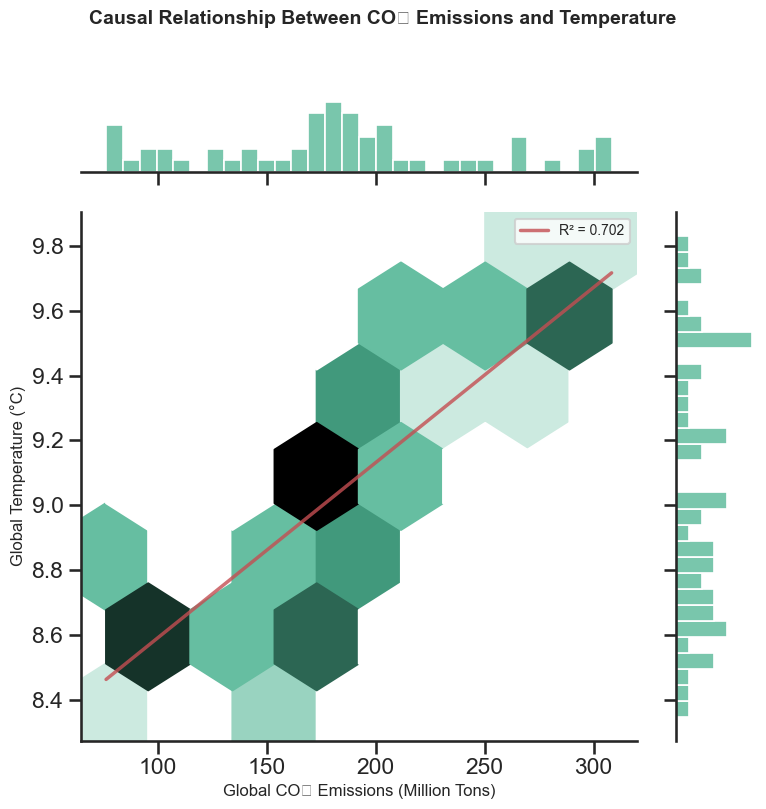

In [36]:
# 图1: CO2与温度Hex JointPlot
if df_co2 is None or df_co2.empty:
    pass
else:
    # 数据准备
    df_co2_yearly = df_co2.groupby('year')['co2_emission'].sum().reset_index()
    df_temp_yearly = df_global.groupby('year')['LandAverageTemperature'].mean().reset_index()
    df_merged = df_co2_yearly.merge(df_temp_yearly, on='year').dropna()
    
    # 创建 hex jointplot
    g = sns.jointplot(
        x=df_merged['co2_emission'] / 1e6, 
        y=df_merged['LandAverageTemperature'],
        kind="hex",
        color="#4CB391",
        height=8,
        ratio=5,
        marginal_kws=dict(bins=30, fill=True)
    )
    
    # 添加回归线
    z = np.polyfit(df_merged['co2_emission'] / 1e6, 
                  df_merged['LandAverageTemperature'], 1)
    p = np.poly1d(z)
    x_line = np.linspace(df_merged['co2_emission'].min() / 1e6, 
                        df_merged['co2_emission'].max() / 1e6, 100)
    r_sq = np.corrcoef(df_merged['co2_emission'], df_merged['LandAverageTemperature'])[0,1]**2
    g.ax_joint.plot(x_line, p(x_line), 'r-', linewidth=2.5, alpha=0.8,
                   label=f'R² = {r_sq:.3f}')
    
    g.set_axis_labels('Global CO₂ Emissions (Million Tons)', 'Global Temperature (°C)', 
                     fontsize=12, weight='medium')
    g.fig.suptitle('Causal Relationship Between CO₂ Emissions and Temperature', 
                  fontsize=14, weight='bold', y=1.02)
    
    g.ax_joint.legend(fontsize=10)
    
    plt.tight_layout()
    plt.show()


In [37]:
# 图2: 城市温度地理散点图（交互式）
import plotly.express as px

# 准备数据（最近10年平均）
max_year = df_city['year'].max()
df_recent = df_city[df_city['year'] >= max_year - 10]

df_map = df_recent.groupby(['City', 'Country', 'Latitude_num', 'Longitude_num']).agg({
    'AverageTemperature': 'mean',
    'AverageTemperatureUncertainty': 'mean'
}).reset_index()

df_map = df_map.dropna(subset=['Latitude_num', 'Longitude_num', 'AverageTemperature'])

# 创建交互式地图
fig = px.scatter_geo(
    df_map,
    lat='Latitude_num',
    lon='Longitude_num',
    color='AverageTemperature',
    size='AverageTemperatureUncertainty',
    hover_name='City',
    hover_data={
        'Country': True,
        'AverageTemperature': ':.2f',
        'AverageTemperatureUncertainty': ':.2f',
        'Latitude_num': False,
        'Longitude_num': False
    },
    color_continuous_scale='Viridis',
    title=f'Global City Average Temperature Distribution ({max_year-10}-{max_year})',
    labels={'AverageTemperature': 'Average Temperature (°C)',
           'AverageTemperatureUncertainty': 'Uncertainty'}
)

fig.update_layout(
    geo=dict(
        showland=True,
        landcolor='rgb(243, 243, 243)',
        coastlinecolor='rgb(204, 204, 204)',
        projection_type='natural earth'
    ),
    width=1400,
    height=800,
    font=dict(size=12)
)

fig.show()


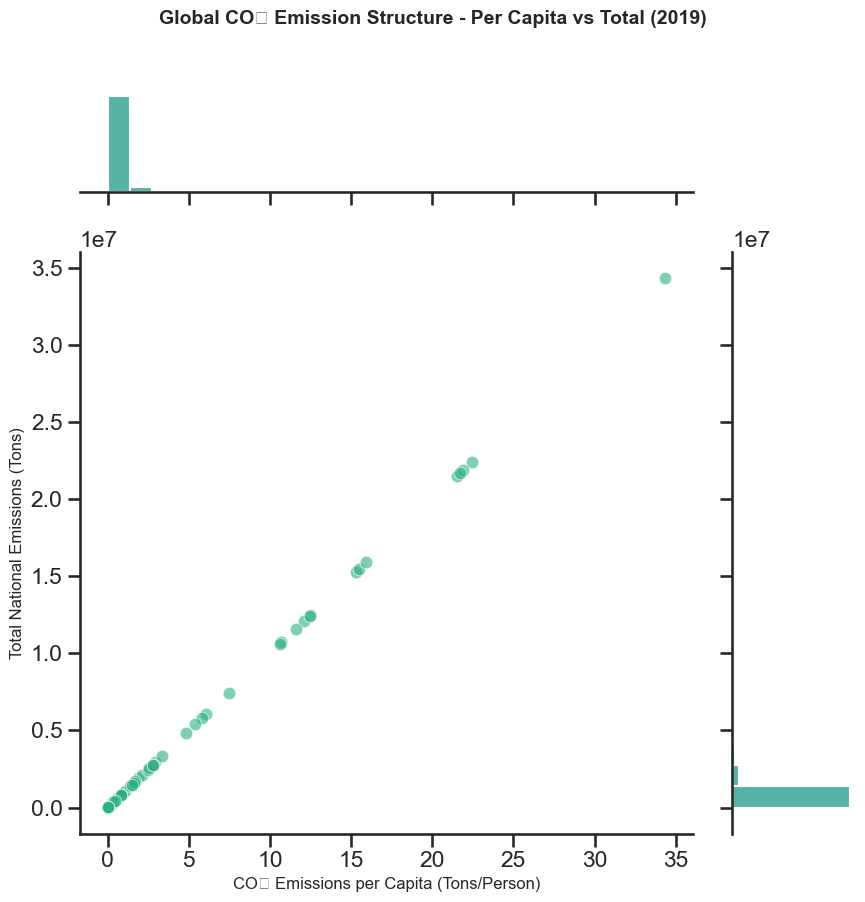

In [38]:
# 图3: CO2分布组合图
if df_co2 is None or df_co2.empty:
    pass
else:
    # 使用最近年份
    latest_year = df_co2['year'].max()
    df_latest = df_co2[df_co2['year'] == latest_year].copy()
    df_latest = df_latest.dropna(subset=['co2_per_capita', 'co2_emission'])
    df_latest = df_latest[df_latest['co2_per_capita'] > 0]
    df_latest = df_latest[df_latest['co2_emission'] > 0]
    
    # 创建简洁的 JointPlot
    g = sns.jointplot(
        data=df_latest, 
        x='co2_per_capita', 
        y='co2_emission',
        kind="scatter",
        height=9,
        ratio=4,
        color=COLORS['viridis'][6],
        alpha=0.6,
        marginal_kws=dict(bins=25, fill=True, color=COLORS['viridis'][5])
    )
    
    g.set_axis_labels('CO₂ Emissions per Capita (Tons/Person)', 'Total National Emissions (Tons)', 
                     fontsize=12, weight='medium')
    g.fig.suptitle(f'Global CO₂ Emission Structure - Per Capita vs Total ({latest_year})', 
                  fontsize=14, weight='bold', y=1.01)
    
    plt.tight_layout()
    plt.show()


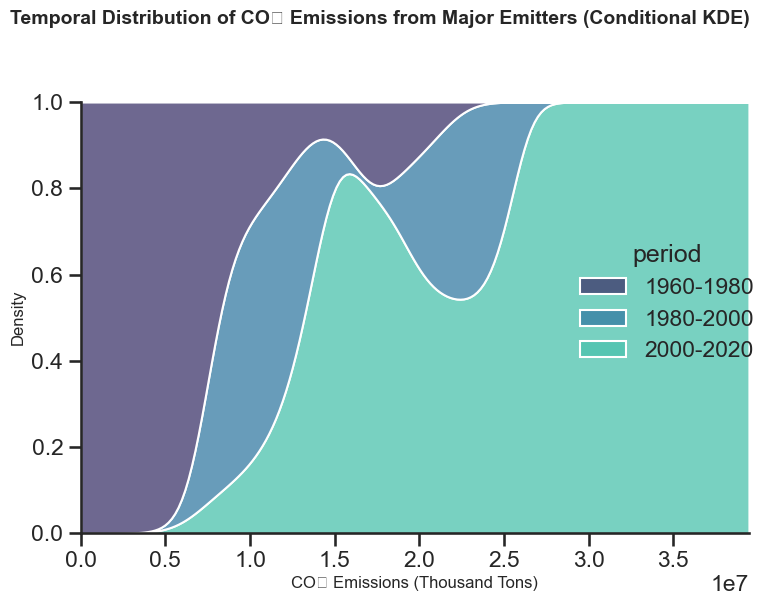

In [ ]:
# 图4: CO2时间条件KDE（条件分布图）
if df_co2 is None or df_co2.empty:
    pass
else:
    # 准备数据：选择主要排放国，按年份和国家聚合
    top_countries = df_co2.groupby('country')['co2_emission'].sum().nlargest(8).index.tolist()
    df_top = df_co2[df_co2['country'].isin(top_countries)].copy()
    
    # 按年份和国家聚合，计算每年的总排放
    df_grouped = df_top.groupby(['year', 'country'])['co2_emission'].sum().reset_index()
    
    # 过滤年份范围（1940-2040，但实际数据可能更短）
    df_grouped = df_grouped[df_grouped['year'] >= 1940]
    df_grouped = df_grouped.dropna(subset=['year', 'country'])
    
    # 使用displot绘制条件KDE（multiple="fill"），显示年份分布
    g = sns.displot(
        data=df_grouped,
        x='year',
        hue='country',
        kind='kde',
        multiple='fill',
        height=6,
        clip=(1940, 2040),
        palette='mako',
        common_norm=False
    )
    
    g.set_axis_labels('Year', 'Density', fontsize=12, weight='medium')
    g.fig.suptitle('Temporal Distribution of Major Emitters (Conditional KDE)', 
                  fontsize=14, weight='bold', y=1.02)
    
    plt.tight_layout()
    plt.show()


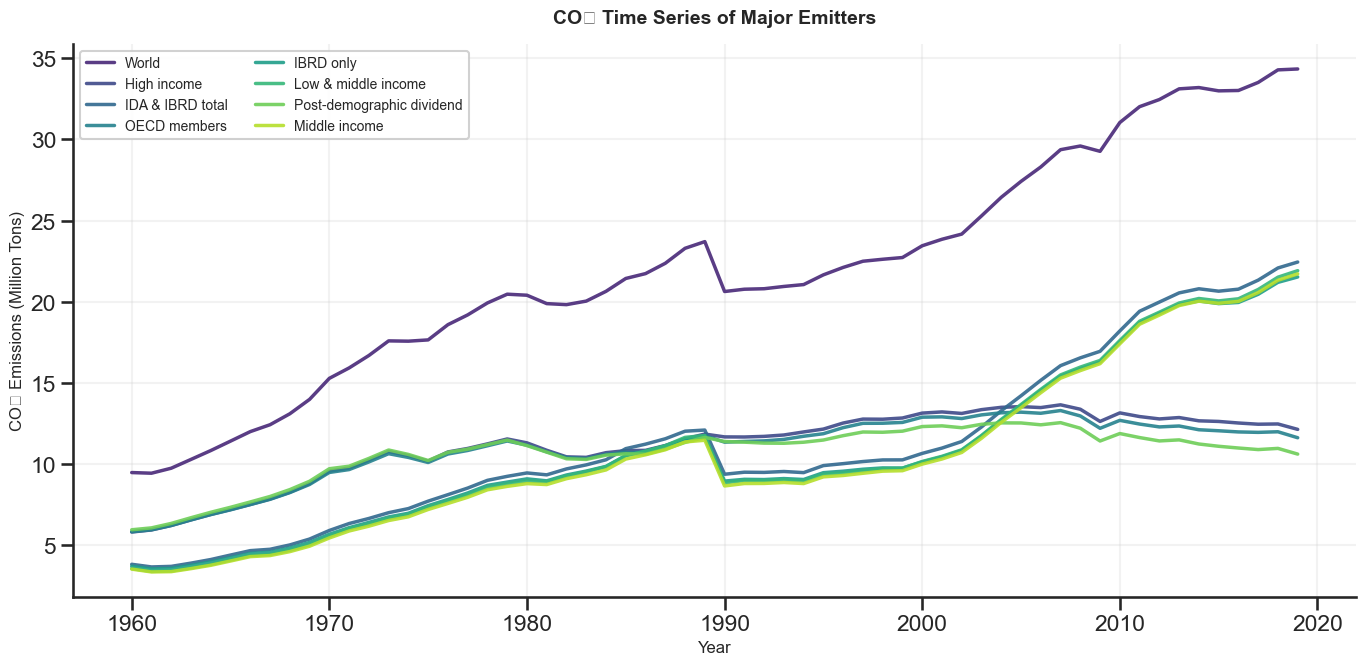

In [40]:
# 图5: CO2时间序列折线图
if df_co2 is None or df_co2.empty:
    pass
else:
    # 准备数据：选择主要排放国
    top_countries = df_co2.groupby('country')['co2_emission'].sum().nlargest(8).index.tolist()
    df_top = df_co2[df_co2['country'].isin(top_countries)].copy()
    
    # 按年份和国家聚合
    df_grouped = df_top.groupby(['year', 'country'])['co2_emission'].sum().reset_index()
    
    # 创建图表
    fig, ax = plt.subplots(figsize=(14, 7))
    
    # 使用 viridis 配色
    palette = sns.color_palette("viridis", n_colors=len(top_countries))
    
    for i, country in enumerate(top_countries):
        df_c = df_grouped[df_grouped['country'] == country]
        ax.plot(df_c['year'], df_c['co2_emission'] / 1e6, 
               linewidth=2.5, label=country, color=palette[i], alpha=0.9)
    
    ax.set_xlabel('Year', fontsize=12, weight='medium')
    ax.set_ylabel('CO₂ Emissions (Million Tons)', fontsize=12, weight='medium')
    ax.set_title('CO₂ Time Series of Major Emitters', 
                fontsize=14, weight='bold', pad=15)
    
    ax.legend(loc='upper left', fontsize=10, frameon=True, 
             framealpha=0.9, ncol=2)
    ax.grid(True, alpha=0.25)
    sns.despine()
    
    plt.tight_layout()
    plt.show()


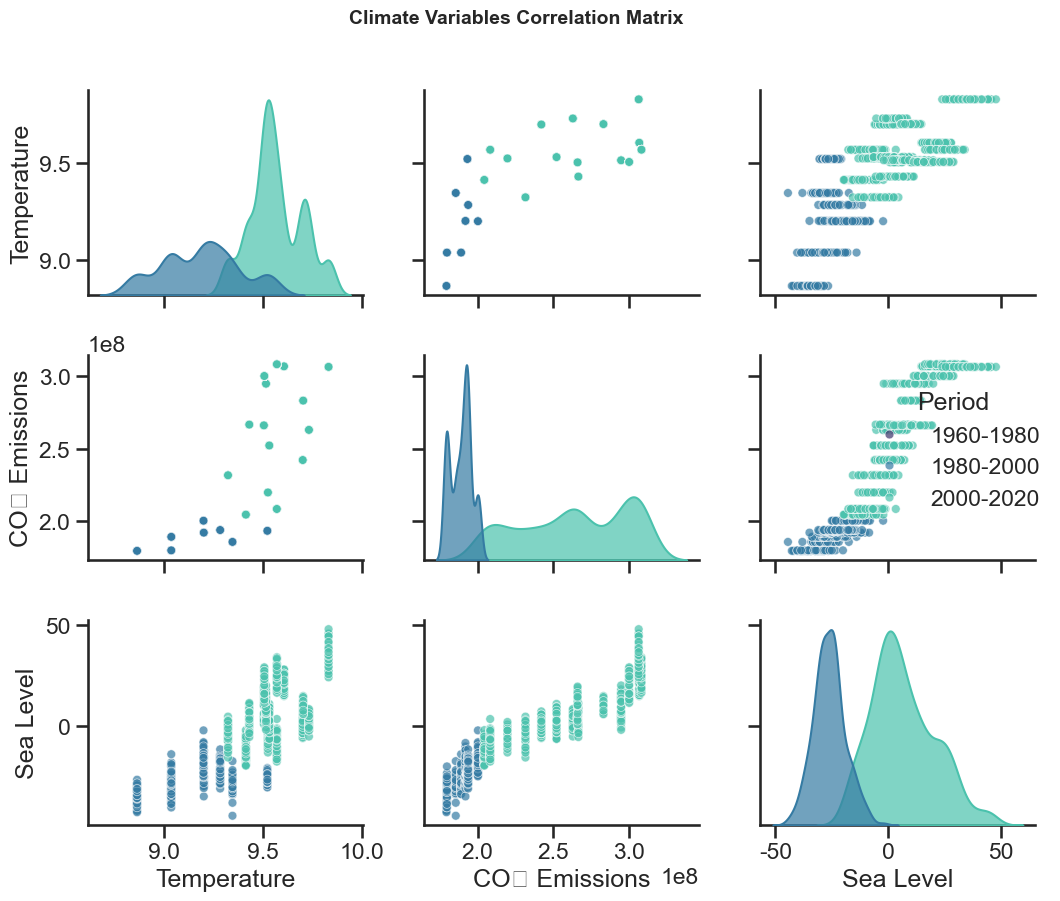

In [41]:
# 图6: PairPlot相关矩阵
# 数据准备
df_temp_yearly = df_global.groupby('year').agg({
    'LandAverageTemperature': 'mean'
}).reset_index()

df_combined = df_temp_yearly.copy()

if df_co2 is not None and not df_co2.empty:
    df_co2_yearly = df_co2.groupby('year')['co2_emission'].sum().reset_index()
    df_combined = df_combined.merge(df_co2_yearly, on='year', how='left')

if df_sea_level is not None and not df_sea_level.empty:
    df_combined = df_combined.merge(df_sea_level[['year', 'sea_level']], 
                                   on='year', how='left')

df_combined = df_combined.dropna()
df_combined['Period'] = pd.cut(df_combined['year'], 
                            bins=[1960, 1980, 2000, 2020],
                            labels=['1960-1980', '1980-2000', '2000-2020'])

# 重命名列（英文）
df_combined = df_combined.rename(columns={
    'LandAverageTemperature': 'Temperature',
    'co2_emission': 'CO₂ Emissions',
    'sea_level': 'Sea Level'
})

plot_vars = ['Temperature', 'CO₂ Emissions', 'Sea Level']
plot_vars = [v for v in plot_vars if v in df_combined.columns]

if len(plot_vars) >= 2:
    # 绘制 PairPlot - 使用 mako 配色
    g = sns.pairplot(df_combined[plot_vars + ['Period']], hue='Period',
                    palette='mako', diag_kind='kde',
                    plot_kws={'alpha': 0.7, 's': 40, 'edgecolor': 'white', 'linewidth': 0.5},
                    diag_kws={'alpha': 0.7},
                    height=3, aspect=1)
    
    g.fig.suptitle('Climate Variables Correlation Matrix', fontsize=14, weight='bold', y=1.01)
    
    plt.tight_layout()
    plt.show()


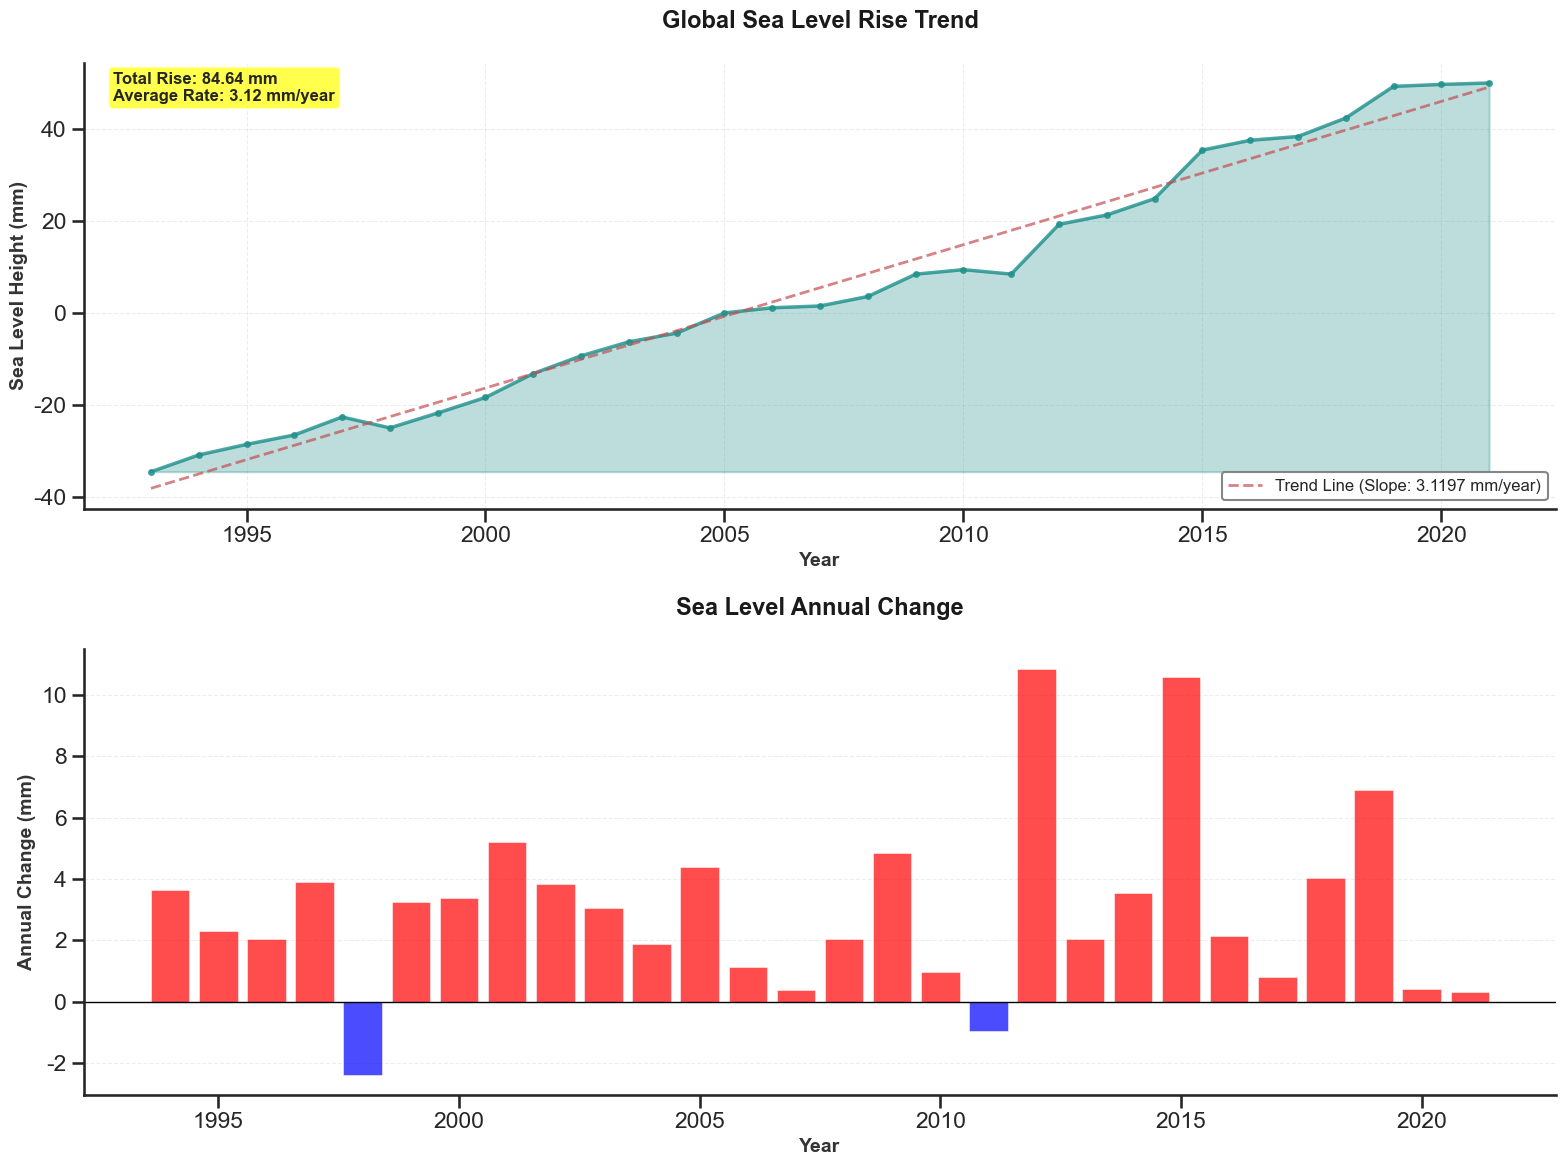

In [42]:
# 图7: 海平面趋势
if df_sea_level is None or df_sea_level.empty:
    pass
else:
    # 找到海平面列（data_loader已经重命名为sea_level）
    if 'sea_level' in df_sea_level.columns:
        sea_level_col = 'sea_level'
    else:
        # 如果没有重命名，尝试查找原始列
        sea_level_col = None
        for col in df_sea_level.columns:
            if 'sea' in col.lower() or 'level' in col.lower() or 'gmsl' in col.lower():
                sea_level_col = col
                break
    
    if sea_level_col is None:
        pass
    else:
        # 按年份聚合
        df_yearly = df_sea_level.groupby('year')[sea_level_col].mean().reset_index()
        df_yearly = df_yearly.dropna()
        df_yearly = df_yearly.sort_values('year')
        
        fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(16, 12))
        
        # 子图1：海平面趋势线图
        viridis_colors = sns.color_palette("viridis", 1)
        ax1.plot(df_yearly['year'], df_yearly[sea_level_col],
                linewidth=2.5, color=viridis_colors[0], marker='o', markersize=4, alpha=0.8)
        
        # 添加趋势线
        z = np.polyfit(df_yearly['year'], df_yearly[sea_level_col], 1)
        p = np.poly1d(z)
        ax1.plot(df_yearly['year'], p(df_yearly['year']), 
               'r--', linewidth=2, label=f'Trend Line (Slope: {z[0]:.4f} mm/year)', alpha=0.7)
        
        # 填充区域
        ax1.fill_between(df_yearly['year'], df_yearly[sea_level_col].min(), df_yearly[sea_level_col],
                        alpha=0.3, color=viridis_colors[0])
        
        ax1.set_xlabel('Year', fontsize=14, fontweight='bold', color='#333333')
        ax1.set_ylabel('Sea Level Height (mm)', fontsize=14, fontweight='bold', color='#333333')
        ax1.set_title('Global Sea Level Rise Trend', 
                     fontsize=17, fontweight='bold', pad=25, color='#1a1a1a')
        ax1.legend(fontsize=12, frameon=True, fancybox=True, framealpha=0.95, edgecolor='gray')
        ax1.grid(True, alpha=0.35, linestyle='--', linewidth=0.8)
        ax1.spines['top'].set_visible(False)
        ax1.spines['right'].set_visible(False)
        
        # 添加统计信息
        total_rise = df_yearly[sea_level_col].max() - df_yearly[sea_level_col].min()
        avg_rate = z[0]  # mm/year
        ax1.text(0.02, 0.98, 
                f'Total Rise: {total_rise:.2f} mm\nAverage Rate: {avg_rate:.2f} mm/year', 
                transform=ax1.transAxes, fontsize=12, fontweight='bold',
                verticalalignment='top', bbox=dict(boxstyle='round', facecolor='yellow', alpha=0.7))
        
        # 子图2：年度变化量
        df_yearly['annual_change'] = df_yearly[sea_level_col].diff()
        rocket_colors = sns.color_palette("rocket_r", 1)
        colors = ['red' if x > 0 else 'blue' for x in df_yearly['annual_change']]
        bars = ax2.bar(df_yearly['year'], df_yearly['annual_change'],
                      color=colors, alpha=0.7, edgecolor='white', linewidth=0.5)
        ax2.axhline(0, color='black', linestyle='-', linewidth=1)
        
        ax2.set_xlabel('Year', fontsize=14, fontweight='bold', color='#333333')
        ax2.set_ylabel('Annual Change (mm)', fontsize=14, fontweight='bold', color='#333333')
        ax2.set_title('Sea Level Annual Change', 
                     fontsize=17, fontweight='bold', pad=25, color='#1a1a1a')
        ax2.grid(axis='y', alpha=0.35, linestyle='--', linewidth=0.8)
        ax2.spines['top'].set_visible(False)
        ax2.spines['right'].set_visible(False)
        
        plt.tight_layout()
        plt.show()


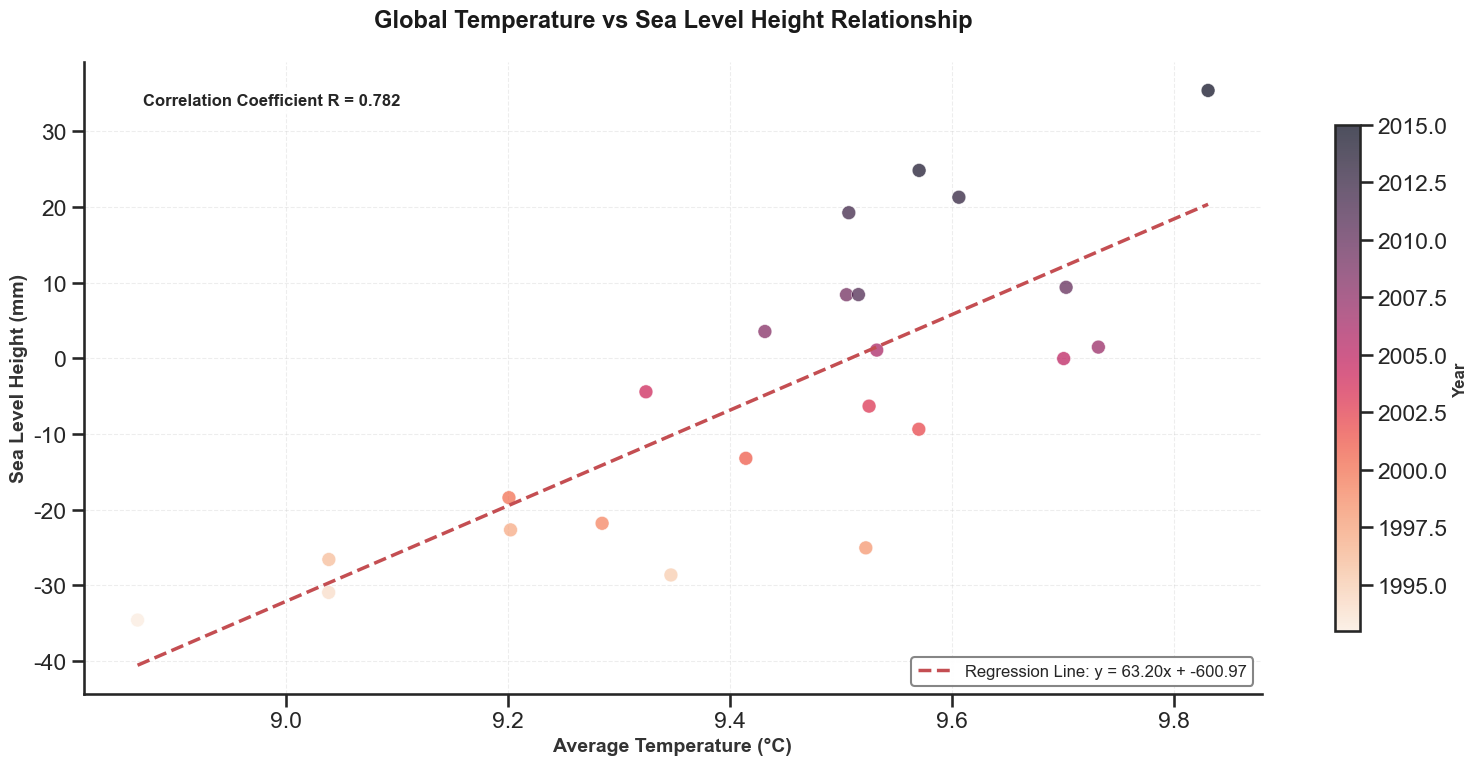

In [43]:
# 图8: 海平面与温度关系
if df_sea_level is None or df_sea_level.empty:
    pass
else:
    # 找到海平面列（data_loader已经重命名为sea_level）
    if 'sea_level' in df_sea_level.columns:
        sea_level_col = 'sea_level'
    else:
        # 如果没有重命名，尝试查找原始列
        sea_level_col = None
        for col in df_sea_level.columns:
            if 'sea' in col.lower() or 'level' in col.lower() or 'gmsl' in col.lower():
                sea_level_col = col
                break
    
    if sea_level_col is None:
        pass
    else:
        # 按年份聚合
        df_sea_yearly = df_sea_level.groupby('year')[sea_level_col].mean().reset_index()
        df_temp_yearly = df_global.groupby('year')['LandAverageTemperature'].mean().reset_index()
        
        # 合并数据
        df_merged = pd.merge(df_sea_yearly, df_temp_yearly, on='year', how='inner')
        df_merged = df_merged.dropna()
        
        if len(df_merged) > 0:
            fig, ax = plt.subplots(figsize=(16, 8))
            
            # 散点图 + 回归线
            ROCKET_R_CMAP = sns.color_palette("rocket_r", as_cmap=True)
            scatter = ax.scatter(df_merged['LandAverageTemperature'], df_merged[sea_level_col],
                               c=df_merged['year'], cmap=ROCKET_R_CMAP,
                               s=100, alpha=0.7, edgecolors='white', linewidth=0.5)
            
            # 添加回归线
            z = np.polyfit(df_merged['LandAverageTemperature'], df_merged[sea_level_col], 1)
            p = np.poly1d(z)
            x_line = np.linspace(df_merged['LandAverageTemperature'].min(), 
                               df_merged['LandAverageTemperature'].max(), 100)
            ax.plot(x_line, p(x_line), 'r--', linewidth=2.5, 
                   label=f'Regression Line: y = {z[0]:.2f}x + {z[1]:.2f}')
            
            # 计算相关系数
            r = np.corrcoef(df_merged['LandAverageTemperature'], df_merged[sea_level_col])[0, 1]
            ax.text(0.05, 0.95, f'Correlation Coefficient R = {r:.3f}', transform=ax.transAxes,
                   fontsize=12, fontweight='bold', verticalalignment='top',
                   bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
            
            ax.set_xlabel('Average Temperature (°C)', fontsize=14, fontweight='bold', color='#333333')
            ax.set_ylabel('Sea Level Height (mm)', fontsize=14, fontweight='bold', color='#333333')
            ax.set_title('Global Temperature vs Sea Level Height Relationship', 
                        fontsize=17, fontweight='bold', pad=25, color='#1a1a1a')
            ax.legend(fontsize=12, frameon=True, fancybox=True, framealpha=0.95, edgecolor='gray')
            ax.grid(True, alpha=0.35, linestyle='--', linewidth=0.8)
            ax.spines['top'].set_visible(False)
            ax.spines['right'].set_visible(False)
            
            cbar = plt.colorbar(scatter, ax=ax, shrink=0.8)
            cbar.set_label('Year', fontsize=12, fontweight='bold', color='#333333')
            
            plt.tight_layout()
            plt.show()


In [44]:
# 所有图表已完成
# others.ipynb包含的图表：
# 1. 04_co2_temp_hexjoint.png - CO2与温度Hex JointPlot
# 2. 03_city_temperature_map.html - 城市温度地理散点图（交互式）
# 3. 05_co2_distribution_combo.png - CO2分布组合图
# 4. 06_co2_time_conditional_kde.png - CO2时间条件KDE
# 5. 06_co2_time_series_lines.png - CO2时间序列折线图
# 6. 08_pairplot_pro.png - PairPlot相关矩阵
# 7. 15_sea_level_trend.png - 海平面趋势
# 8. 16_sea_level_vs_temperature.png - 海平面与温度关系
